In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/food_delivery_dataset_realistic_80000.csv")
df.head(10)

,Order_ID,City,Customer_Age,Customer_Gender,Restaurant_Rating,Cuisine_Type,Distance_km,Traffic_Level,Order_Value,Number_of_Items,Discount,Payment_Method,Delivery_Partner_Rating,Delivery_Time_minutes,Order_Status
0,100000,Delhi,59.0,Female,4.25,North Indian,3.28,Medium,600.60,1,76.84,UPI,4.51,27.0,Delivered
1,100001,Kolkata,41.0,Male,4.41,Fast Food,9.25,Low,1128.64,3,110.34,UPI,4.25,38.0,Delivered
2,100002,Ahmedabad,30.0,Male,4.01,North Indian,5.35,Low,410.53,3,13.46,UPI,3.39,29.0,Delivered
3,100003,Hyderabad,52.0,Female,4.69,Pizza,1.15,Low,917.76,1,50.56,UPI,3.87,37.0,Delivered
4,100004,Mumbai,33.0,Male,5.00,Chinese,7.28,Low,484.27,4,69.38,Card,4.91,17.0,Delivered
5,100005,Mumbai,21.0,Female,4.78,South Indian,1.95,Low,613.36,2,52.03,UPI,4.64,36.0,Delivered
6,100006,Mumbai,20.0,Female,4.53,South Indian,2.74,High,204.94,3,58.43,UPI,3.11,41.0,Delivered
7,100007,Chennai,51.0,Female,3.61,Chinese,6.39,Medium,1196.25,5,27.19,UPI,4.35,30.0,Delivered
8,100008,Hyderabad,32.0,Male,3.89,Burger,7.76,Medium,389.98,1,46.23,UPI,3.63,29.0,Delivered
9,100009,Ahmedabad,48.0,Male,3.06,South Indian,6.67,Medium,144.27,6,23.13,Card,3.64,34.0,Delivered


In [3]:
df.shape

(80000, 15)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 80000 non-null  int64  
 1   City                     80000 non-null  object 
 2   Customer_Age             78400 non-null  float64
 3   Customer_Gender          80000 non-null  object 
 4   Restaurant_Rating        78400 non-null  float64
 5   Cuisine_Type             80000 non-null  object 
 6   Distance_km              80000 non-null  float64
 7   Traffic_Level            80000 non-null  object 
 8   Order_Value              80000 non-null  float64
 9   Number_of_Items          80000 non-null  int64  
 10  Discount                 78400 non-null  float64
 11  Payment_Method           80000 non-null  object 
 12  Delivery_Partner_Rating  80000 non-null  float64
 13  Delivery_Time_minutes    80000 non-null  float64
 14  Order_Status          

In [5]:
df.isnull().sum()

,0
Order_ID,0
City,0
Customer_Age,1600
Customer_Gender,0
Restaurant_Rating,1600
Cuisine_Type,0
Distance_km,0
Traffic_Level,0
Order_Value,0
Number_of_Items,0


In [6]:
df["Customer_Age"]=df["Customer_Age"].fillna(df["Customer_Age"].median())
df["Restaurant_Rating"]=df["Restaurant_Rating"].fillna(df["Restaurant_Rating"].median())
df["Discount"]=df["Discount"].fillna(df["Discount"].median())

In [7]:
df.isnull().sum()

,0
Order_ID,0
City,0
Customer_Age,0
Customer_Gender,0
Restaurant_Rating,0
Cuisine_Type,0
Distance_km,0
Traffic_Level,0
Order_Value,0
Number_of_Items,0


In [8]:
df.describe()

,Order_ID,Customer_Age,Restaurant_Rating,Distance_km,Order_Value,Number_of_Items,Discount,Delivery_Partner_Rating,Delivery_Time_minutes
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,139999.500000,38.447488,4.002080,5.245203,659.780325,3.497762,74.979461,4.000298,30.014388
std,23094.155105,11.992251,0.571192,2.745481,311.629158,1.709051,42.851957,0.577638,8.008775
min,100000.000000,18.000000,3.000000,0.500000,120.000000,1.000000,0.000000,3.000000,-2.000000
25%,119999.750000,28.000000,3.510000,2.880000,391.300000,2.000000,38.197500,3.500000,25.000000
50%,139999.500000,38.000000,4.000000,5.250000,657.775000,3.000000,75.120000,4.000000,30.000000
75%,159999.250000,49.000000,4.490000,7.620000,929.160000,5.000000,111.480000,4.500000,35.000000
max,179999.000000,59.000000,5.000000,10.000000,1199.990000,6.000000,150.000000,5.000000,64.000000


In [9]:
df["Customer_Age"]=df["Customer_Age"].astype("int64")
df["Order_Value"]=df["Order_Value"].astype("int64")

In [10]:
df["Customer_Age"].unique()

array([59, 41, 30, 52, 33, 21, 20, 51, 32, 48, 18, 50, 43, 54, 25, 19, 35,
       27, 29, 56, 39, 58, 38, 47, 23, 55, 28, 24, 37, 40, 26, 46, 53, 49,
       31, 36, 45, 44, 22, 57, 42, 34])

In [11]:
df["Customer_Age"].max()

59

In [12]:
df["Customer_Age"].min()

18

In [13]:
def extract(a):
  if a>=18 and a<=30:
    return "young"
  elif a>30 and a<=45:
    return "middle age"
  else:
    return "old"
df["age_category"]=df["Customer_Age"].apply(extract)

In [14]:
df["age_category"].unique()

array(['old', 'middle age', 'young'], dtype=object)

In [15]:
df["revenue"]=df["Order_Value"]-df["Discount"]
df["revenue"]=df["revenue"].clip(lower=0)
df.loc[df["Order_Status"]=="Cancelled","revenue"]=0

In [16]:
df.head(10)

,Order_ID,City,Customer_Age,Customer_Gender,Restaurant_Rating,Cuisine_Type,Distance_km,Traffic_Level,Order_Value,Number_of_Items,Discount,Payment_Method,Delivery_Partner_Rating,Delivery_Time_minutes,Order_Status,age_category,revenue
0,100000,Delhi,59,Female,4.25,North Indian,3.28,Medium,600,1,76.84,UPI,4.51,27.0,Delivered,old,523.16
1,100001,Kolkata,41,Male,4.41,Fast Food,9.25,Low,1128,3,110.34,UPI,4.25,38.0,Delivered,middle age,1017.66
2,100002,Ahmedabad,30,Male,4.01,North Indian,5.35,Low,410,3,13.46,UPI,3.39,29.0,Delivered,young,396.54
3,100003,Hyderabad,52,Female,4.69,Pizza,1.15,Low,917,1,50.56,UPI,3.87,37.0,Delivered,old,866.44
4,100004,Mumbai,33,Male,5.00,Chinese,7.28,Low,484,4,69.38,Card,4.91,17.0,Delivered,middle age,414.62
5,100005,Mumbai,21,Female,4.78,South Indian,1.95,Low,613,2,52.03,UPI,4.64,36.0,Delivered,young,560.97
6,100006,Mumbai,20,Female,4.53,South Indian,2.74,High,204,3,58.43,UPI,3.11,41.0,Delivered,young,145.57
7,100007,Chennai,51,Female,3.61,Chinese,6.39,Medium,1196,5,27.19,UPI,4.35,30.0,Delivered,old,1168.81
8,100008,Hyderabad,32,Male,3.89,Burger,7.76,Medium,389,1,46.23,UPI,3.63,29.0,Delivered,middle age,342.77
9,100009,Ahmedabad,48,Male,3.06,South Indian,6.67,Medium,144,6,23.13,Card,3.64,34.0,Delivered,old,120.87


In [17]:
df.groupby("Order_Status")["revenue"].describe()

,count,mean,std,min,25%,50%,75%,max
Order_Status,,,,,,,,
Cancelled,6319.0,0.000000,0.000000,0.0,0.0,0.00,0.00,0.00
Delivered,73681.0,584.249517,314.752275,0.0,315.3,581.15,854.66,1198.82


In [18]:
df["Profit"]=df["revenue"]*0.25
df["Profit"]

,Profit
0,130.7900
1,254.4150
2,99.1350
3,216.6100
4,103.6550
...,...
79995,191.0975
79996,163.4900
79997,150.4725
79998,205.0925


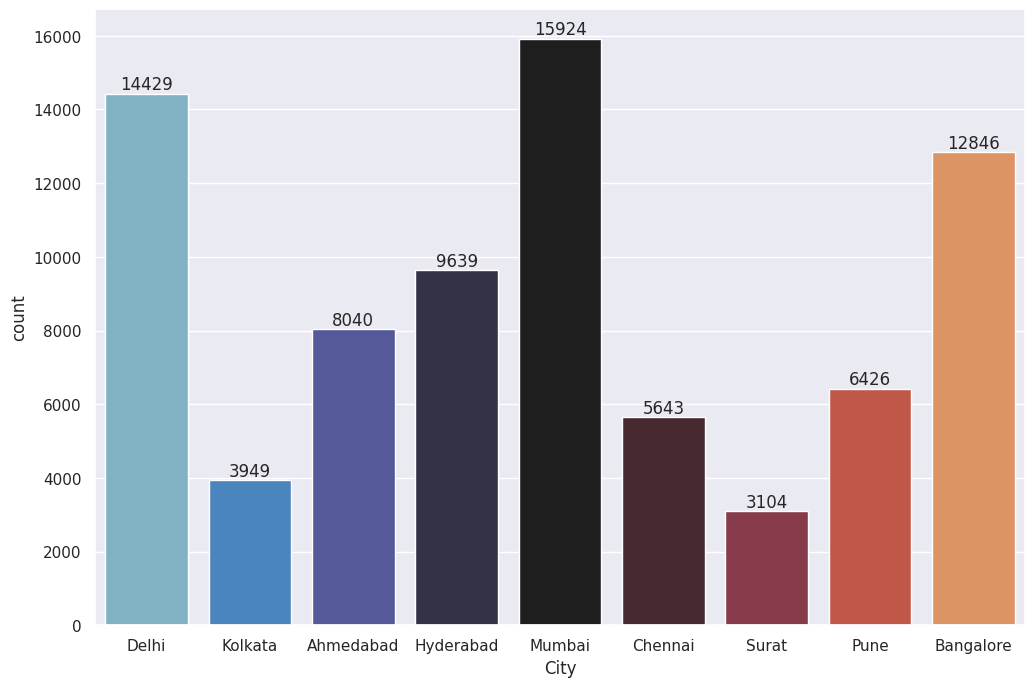

In [19]:
sns.set(rc={"figure.figsize":(12,8)})
m=sns.countplot(data=df,x="City",hue="City",legend=False,palette="icefire")
for i in m.containers:
  m.bar_label(i)

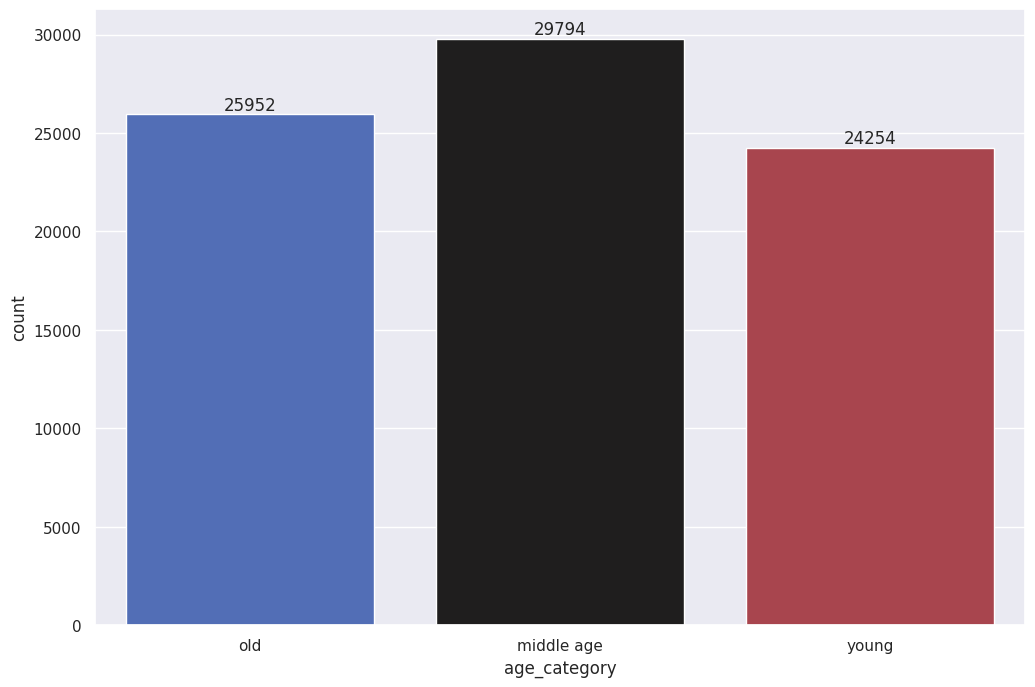

In [20]:
o=sns.countplot(data=df,x="age_category",hue="age_category",legend=False,palette="icefire")
for i in o.containers:
  o.bar_label(i)

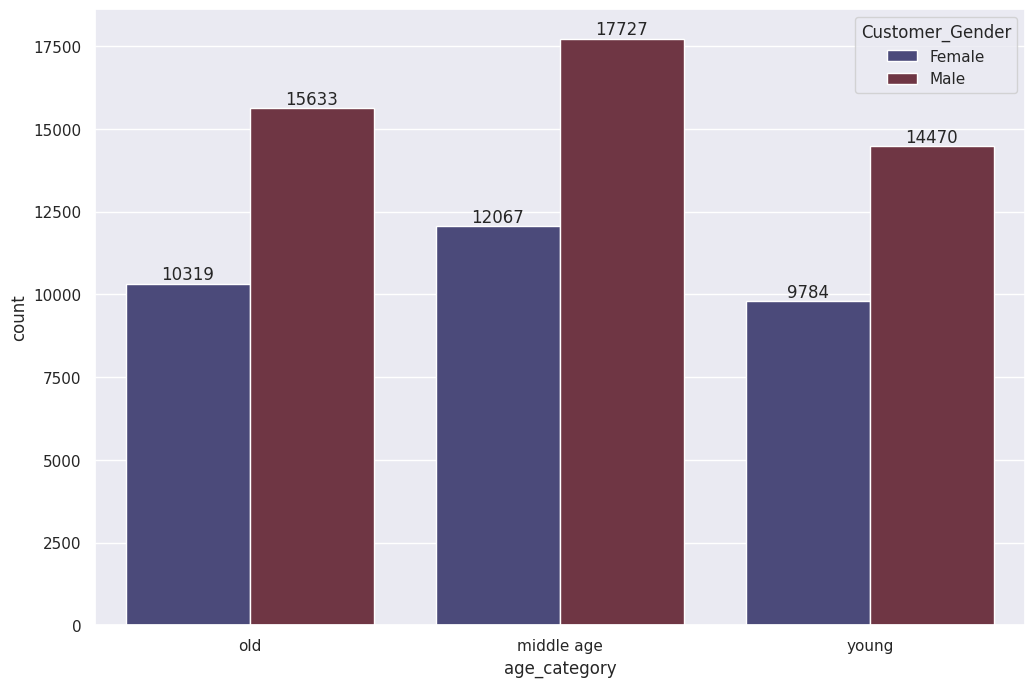

In [21]:
m=sns.countplot(data=df,x="age_category",hue="Customer_Gender",palette="icefire")
for i in m.containers:
  m.bar_label(i)

In [22]:
v=df.groupby(["Cuisine_Type","age_category"],as_index=False)["Order_ID"].count().sort_values(by="Order_ID",ascending=False)
v

,Cuisine_Type,age_category,Order_ID
0,Biryani,middle age,3787
9,Desserts,middle age,3760
21,South Indian,middle age,3748
3,Burger,middle age,3725
6,Chinese,middle age,3725
18,Pizza,middle age,3707
15,North Indian,middle age,3678
12,Fast Food,middle age,3664
10,Desserts,old,3403
13,Fast Food,old,3319


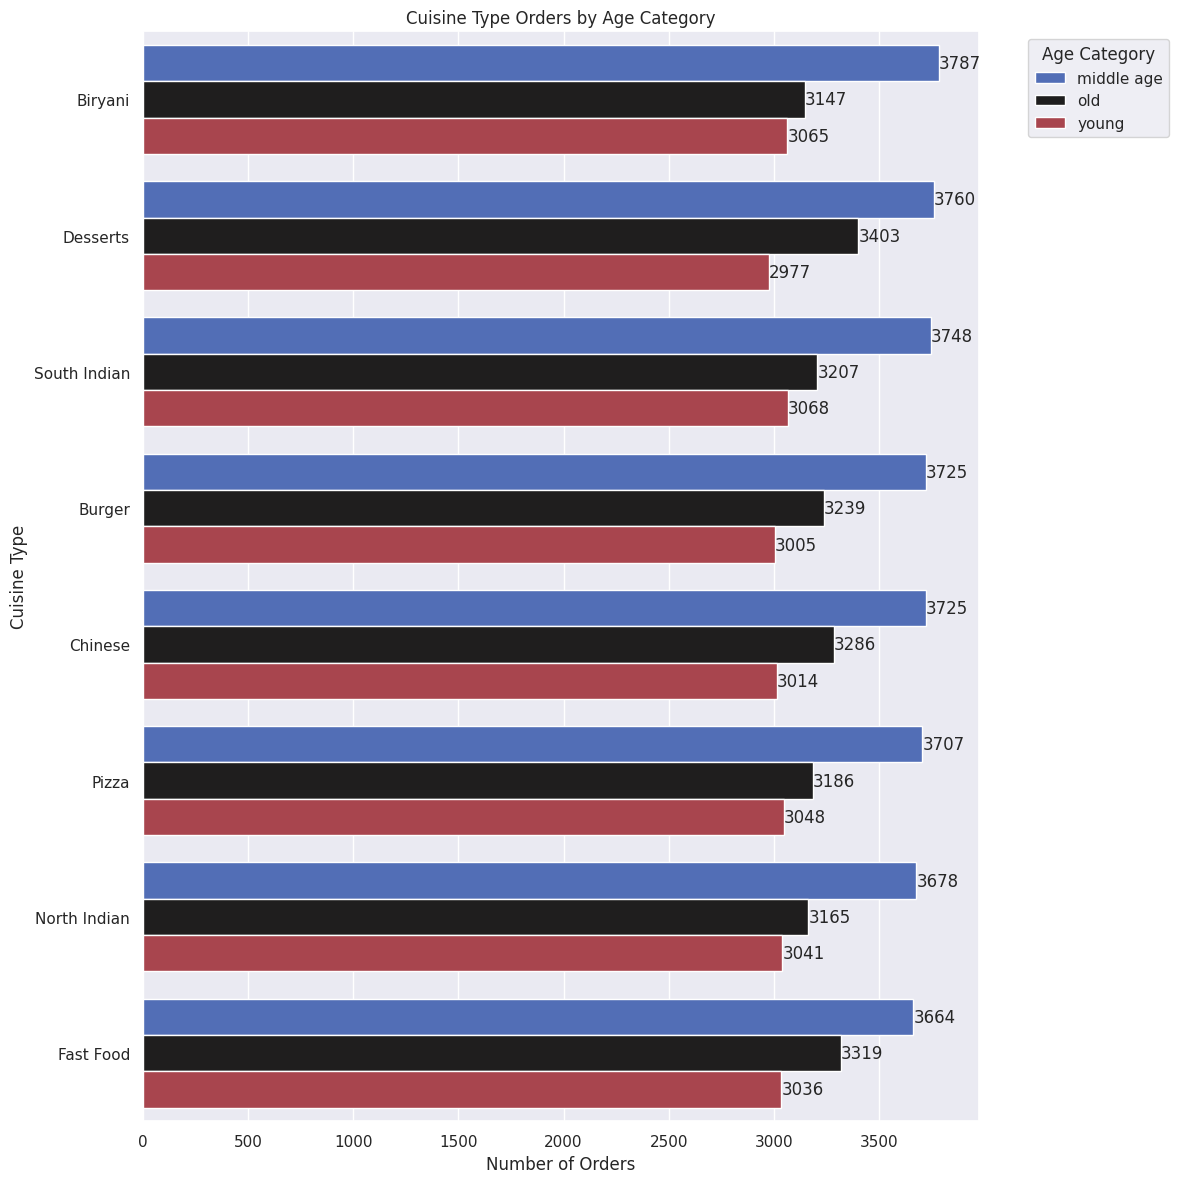

In [23]:
sns.set(rc={"figure.figsize":(12,12)})
m=sns.barplot(data=v, y="Cuisine_Type", x="Order_ID", hue="age_category", palette="icefire")
for i in m.containers:
  m.bar_label(i)
m.set_title("Cuisine Type Orders by Age Category")
m.set_xlabel("Number of Orders")
m.set_ylabel("Cuisine Type")
m.legend(title="Age Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [24]:
df.head()

,Order_ID,City,Customer_Age,Customer_Gender,Restaurant_Rating,Cuisine_Type,Distance_km,Traffic_Level,Order_Value,Number_of_Items,Discount,Payment_Method,Delivery_Partner_Rating,Delivery_Time_minutes,Order_Status,age_category,revenue,Profit
0,100000,Delhi,59,Female,4.25,North Indian,3.28,Medium,600,1,76.84,UPI,4.51,27.0,Delivered,old,523.16,130.790
1,100001,Kolkata,41,Male,4.41,Fast Food,9.25,Low,1128,3,110.34,UPI,4.25,38.0,Delivered,middle age,1017.66,254.415
2,100002,Ahmedabad,30,Male,4.01,North Indian,5.35,Low,410,3,13.46,UPI,3.39,29.0,Delivered,young,396.54,99.135
3,100003,Hyderabad,52,Female,4.69,Pizza,1.15,Low,917,1,50.56,UPI,3.87,37.0,Delivered,old,866.44,216.610
4,100004,Mumbai,33,Male,5.00,Chinese,7.28,Low,484,4,69.38,Card,4.91,17.0,Delivered,middle age,414.62,103.655


In [28]:
v=df.groupby("City",as_index=False)["revenue"].sum()
v

,City,revenue
0,Ahmedabad,4347873.78
1,Bangalore,6896453.29
2,Chennai,3063401.33
3,Delhi,7796588.21
4,Hyderabad,5159504.89
5,Kolkata,2105962.80
6,Mumbai,8583378.42
7,Pune,3443602.80
8,Surat,1651323.16


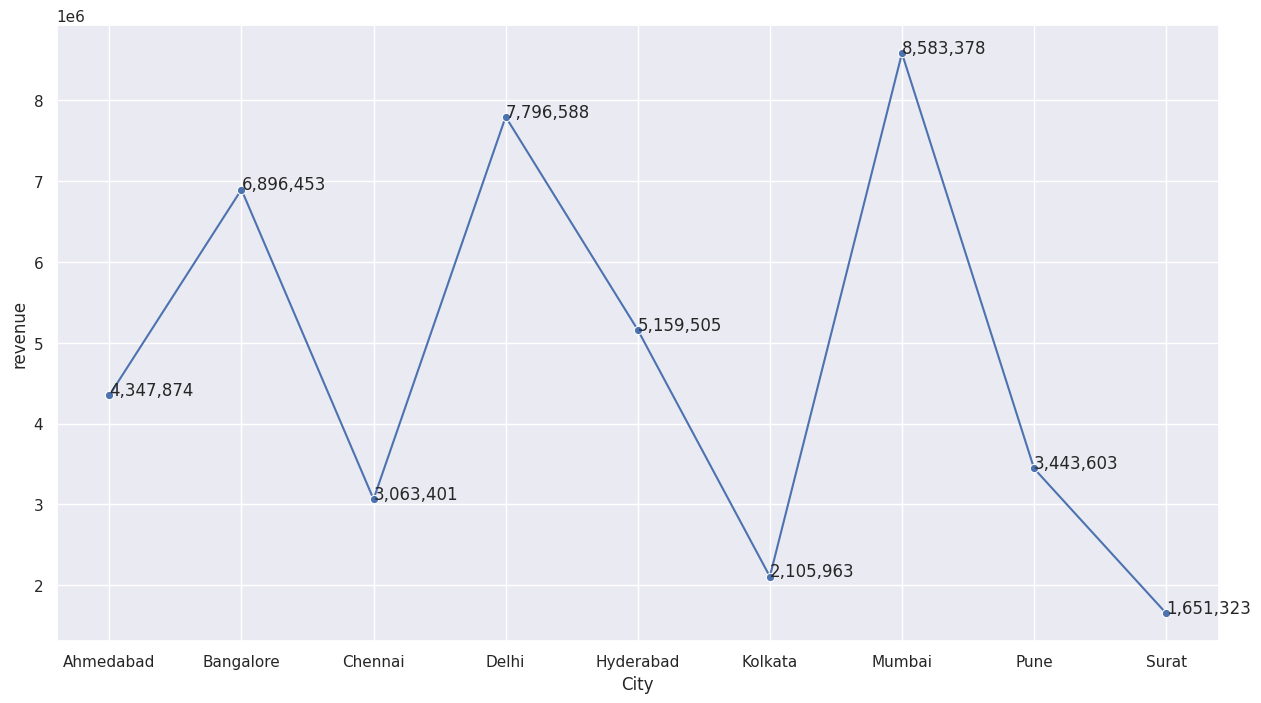

In [41]:
sns.set(rc={"figure.figsize":(15,8)})
sns.lineplot(data=v,x="City",y="revenue",marker="o")
for x,y in zip(v["City"],v["revenue"]):
  plt.text(x,y,f'{y:,.0f}')

In [48]:
l=df.groupby("City",as_index=False)["Profit"].sum()
l

,City,Profit
0,Ahmedabad,1.086968e+06
1,Bangalore,1.724113e+06
2,Chennai,7.658503e+05
3,Delhi,1.949147e+06
4,Hyderabad,1.289876e+06
5,Kolkata,5.264907e+05
6,Mumbai,2.145845e+06
7,Pune,8.609007e+05
8,Surat,4.128308e+05


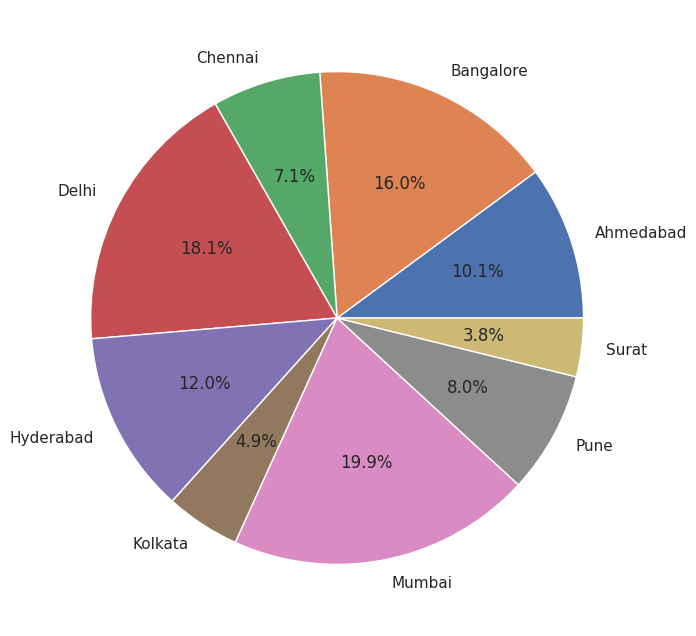

In [50]:
plt.pie(l["Profit"],labels=l["City"],autopct="%1.1f%%")
plt.show()

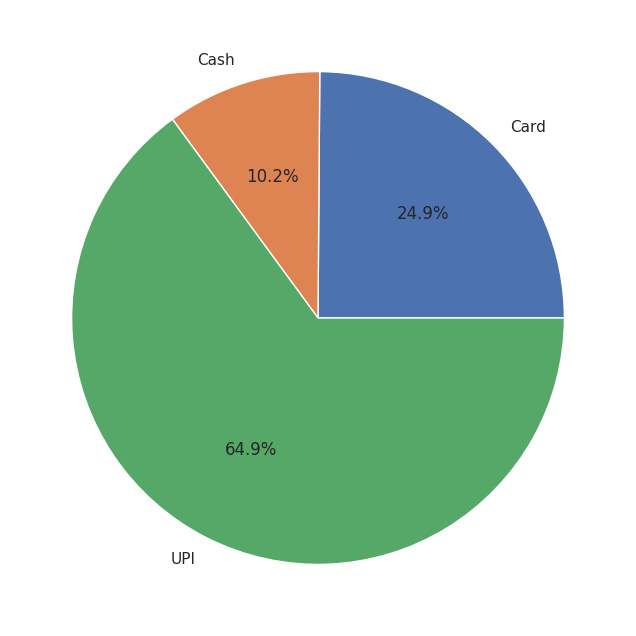

In [76]:
b=df.groupby("Payment_Method",as_index=False)["revenue"].sum()
plt.pie(b["revenue"],labels=b["Payment_Method"],autopct="%1.1f%%")
plt.show()

In [53]:
f=df.groupby("Order_Status",as_index=False)["Order_ID"].count()
f

,Order_Status,Order_ID
0,Cancelled,6319
1,Delivered,73681


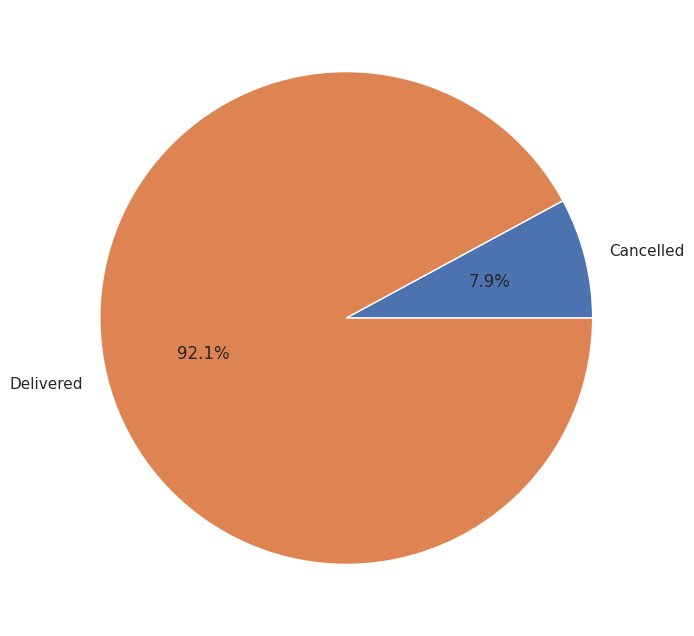

In [54]:
plt.pie(f["Order_ID"],labels=f["Order_Status"],autopct="%1.1f%%")
plt.show()

In [55]:
f=df.groupby(["Order_Status","City"],as_index=False)["Order_ID"].count()
f

,Order_Status,City,Order_ID
0,Cancelled,Ahmedabad,659
1,Cancelled,Bangalore,1042
2,Cancelled,Chennai,438
3,Cancelled,Delhi,1111
4,Cancelled,Hyderabad,746
5,Cancelled,Kolkata,322
6,Cancelled,Mumbai,1221
7,Cancelled,Pune,509
8,Cancelled,Surat,271
9,Delivered,Ahmedabad,7381


<Axes: xlabel='City', ylabel='Order_ID'>

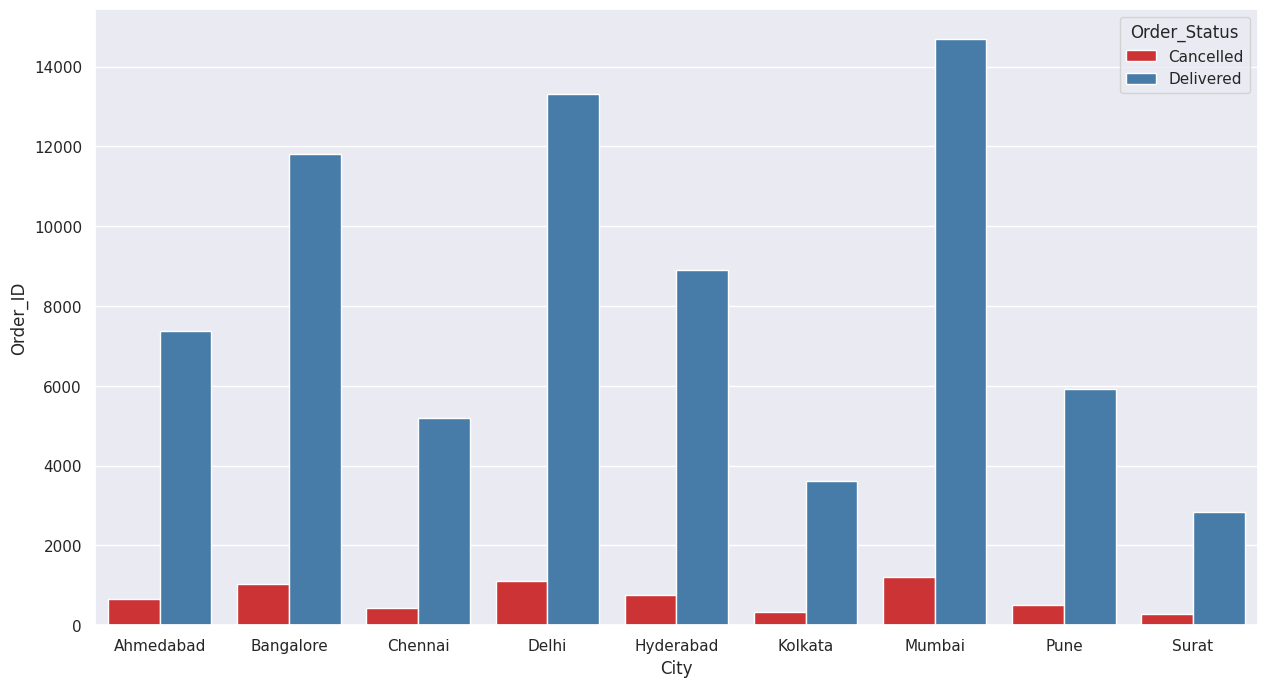

In [70]:
sns.barplot(data=f,x="City",y="Order_ID",hue="Order_Status",palette="Set1")

<Axes: >

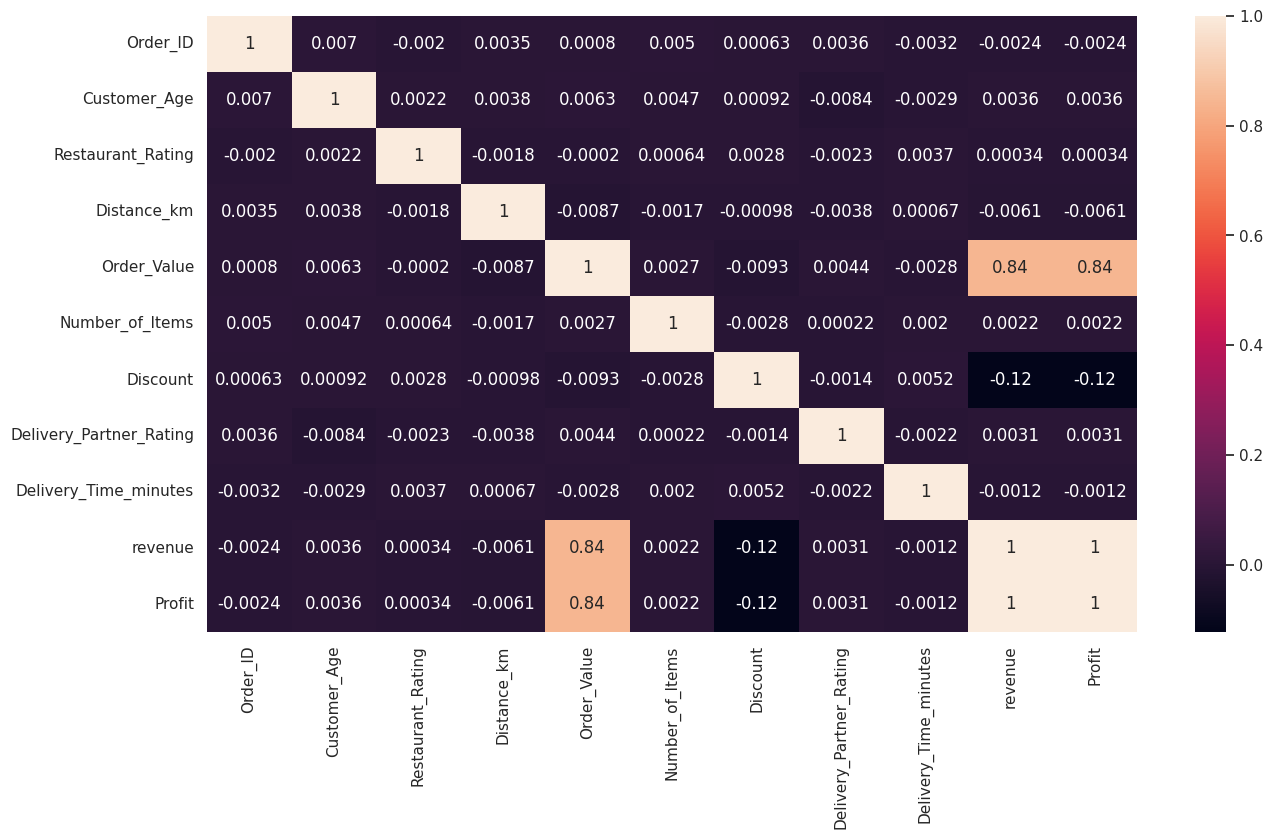

In [71]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

## Summary of Data Analysis

This analysis explores a food delivery dataset to understand customer behavior, order patterns, and revenue generation.

### 1. Data Loading and Cleaning

The dataset, containing 80,000 entries and 15 columns, was loaded into a pandas DataFrame. Initial inspection revealed missing values in 'Customer_Age', 'Restaurant_Rating', and 'Discount' columns. These missing values were imputed using the median of their respective columns to maintain data integrity. Additionally, 'Customer_Age' and 'Order_Value' columns were converted to integer data types for consistency and easier analysis.

### 2. Feature Engineering

Several new features were engineered to enrich the dataset:
- **age_category**: A new categorical column was created from 'Customer_Age', classifying customers into 'young' (18-30), 'middle age' (31-45), and 'old' (46-59).
- **revenue**: Calculated as 'Order_Value' minus 'Discount'. Importantly, for orders with 'Order_Status' as 'Cancelled', the revenue was set to 0, and revenue was clipped at a minimum of 0 to handle potential negative values.
- **Profit**: Derived by taking 25% of the calculated 'revenue'.

### 3. Key Insights from Visualizations

- **City Distribution**: The dataset includes orders from various cities, with Mumbai, Delhi, and Bangalore having the highest number of orders.
- **Age and Gender Distribution**: The customer base is relatively evenly distributed across 'young', 'middle age', and 'old' age categories. Customer genders are also fairly balanced, with a slight tilt towards males in some age groups.
- **Cuisine Type by Age Category**: 'Biryani', 'Desserts', and 'South Indian' are popular across all age categories, with 'middle age' customers generally placing more orders for these cuisines compared to 'young' and 'old' customers.
- **Revenue by City**: Mumbai stands out as the highest revenue-generating city, followed by Delhi and Bangalore. Surat and Kolkata generate the least revenue.
- **Profit Distribution by City**: Reflecting the revenue, Mumbai contributes the largest share to overall profit (21.5%), followed by Delhi (19.5%) and Bangalore (17.2%). Surat has the lowest profit contribution (4.1%).
- **Payment Method Preference**: UPI is the most preferred payment method, accounting for approximately 64% of total revenue, followed by Card (24.7%) and Cash (10.6%).
- **Order Status**: The vast majority of orders (92.1%) are 'Delivered', while 7.9% are 'Cancelled'.
- **Cancelled Orders by City**: Mumbai, Delhi, and Bangalore have the highest number of cancelled orders, which aligns with them having the highest total order volumes. This indicates that while these cities drive high volume, they also experience a proportional number of cancellations.
- **Correlation Analysis**: The heatmap shows positive correlations between `Order_Value` and `Number_of_Items` as expected. There are also some interesting positive correlations between `Restaurant_Rating` and `Delivery_Partner_Rating`, suggesting that higher-rated restaurants might be associated with higher-rated delivery partners.